In [ ]:
import torch
from torchvision import transforms, models
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [ ]:

from utils.Config import Config

cfg = Config.from_yaml("config.yaml")
cfg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Config(data_path='./res', batch_size=32, learning_rate=0.0001, epochs=15, patience=3, loss='CrossEntropy', optimizer='Adam', fine_tuning=True, use_augmentation=True, resume_training=False, checkpoint_dir='./checkpoints', model_name='Augmentation_4_30_001')

In [37]:
from utils.dataDownloader import download_data

if(cfg.download_data):
    download_data()

AttributeError: 'Config' object has no attribute 'download_data'

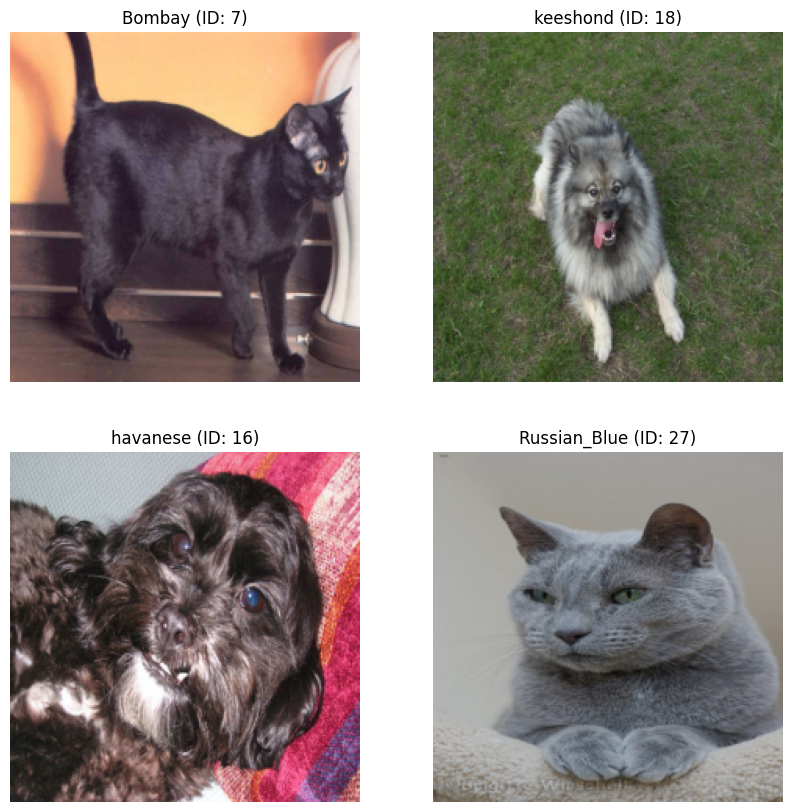

In [ ]:

# Statistiche standard di ImageNet (usate da ResNet/VGG)
# È fondamentale usare queste se fai Transfer Learning
mean_stats = [0.485, 0.456, 0.406]
std_stats  = [0.229, 0.224, 0.225]

# Data Augmentation per il training set

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),       
    transforms.RandomRotation(15),   
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean_stats, std_stats)
])


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),            
    transforms.Normalize(mean_stats, std_stats)
])

In [ ]:
from utils.OxfordPets import OxfordPetsDataset

full_train_ds = OxfordPetsDataset(root_dir='res', transform=train_transforms)

full_test_ds = OxfordPetsDataset(root_dir='res', transform=test_transforms)

total_len = len(full_train_ds)
indices = list(range(total_len))

# Necessario perché il dataset è ordinato per razze
np.random.shuffle(indices)

train_split = int(0.7 * total_len)
val_split   = int(0.15 * total_len)
# Il resto va al test

train_indices = indices[:train_split]
val_indices   = indices[train_split : train_split + val_split]
test_indices  = indices[train_split + val_split :]


train_dataset = Subset(full_train_ds, train_indices)

val_dataset   = Subset(full_test_ds, val_indices)

test_dataset  = Subset(full_test_ds, test_indices)

print(f"Train: {len(train_dataset)} immagini")
print(f"Val:   {len(val_dataset)} immagini")
print(f"Test:  {len(test_dataset)} immagini")

In [ ]:

# Mostriamo alcune delle immagini per verificare che siano presenti
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

idx_to_class = {}
with open('res/annotations/list.txt', 'r') as f:
    for line in f:
        if line.startswith('#'): continue
        parts = line.strip().split()
        if len(parts) >= 2:
            breed_name = parts[0].rsplit('_', 1)[0]
            class_id = int(parts[1]) - 1
            idx_to_class[class_id] = breed_name

figure = plt.figure(figsize=(10, 10))
cols, rows = 2, 2

for i in range(1, cols * rows + 1):
    # Le prendiamo dal test set direttamente
    sample_idx = torch.randint(len(test_dataset), size=(1,)).item()
    img, label = test_dataset[sample_idx]
    
    figure.add_subplot(rows, cols, i)
    plt.title(f"{idx_to_class.get(label, label)} (ID: {label})")
    plt.axis("off")
    
    # Operazioni per visualizzare
    img_np = img.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    plt.imshow(img_np)

plt.show()

Stiamo usando il dispositivo: cpu


In [ ]:


class ImprovedCustomCNN(nn.Module):
    def __init__(self):
        super(ImprovedCustomCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) 
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Utilizziamo Dropout per ridurre overfitting, mandando a zero una percentuale di neuroni negli hidden layers
        self.dropout = nn.Dropout(0.5)
        
        # Calcolo dimensione per il layer lineare:
        # Input 224x224
        # Pool1 -> 112
        # Pool2 -> 56
        # Pool3 -> 28
        # Pool4 -> 14
        # Uscita finale: 256 canali * 14 * 14 pixel
        self.flatten_size = 256 * 14 * 14
        
        self.fc1 = nn.Linear(self.flatten_size, 512)
        self.bn_fc1 = nn.BatchNorm1d(512) 
        self.fc2 = nn.Linear(512, 37) # Le classi totali sono 37, quindi servono 37 neuroni nel livello finale

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)
        
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.pool(x)
        
        x = x.view(-1, self.flatten_size)
        
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

model = ImprovedCustomCNN()
# model.to(device)

Inizio Addestramento...
[Epoca 1, Batch 50] loss: 3.612
[Epoca 1, Batch 100] loss: 3.611


KeyboardInterrupt: 

In [ ]:


"""
 Questa classe serve a modellare l'early stopping, quando la loss del training set diminuisce ma quella del validation set sale, 
 stiamo andando incontro al fenomeno dell'overfitting.
 Quando succede per un determinato numero di epoche fermiamo il training e consideriamo come modello allenato l'ultimo prima che iniziasse questo fenomeno.
"""

class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0):
        """
        Args:
            patience (int): Quante epoche aspettare dopo l'ultimo miglioramento.
            verbose (bool): Se True, stampa un messaggio a ogni miglioramento.
            delta (float): Minimo cambiamento da considerare come miglioramento.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Salva il modello quando la validation loss diminuisce.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        self.best_model_wts = model.state_dict() # Salva i pesi in memoria
        self.val_loss_min = val_loss
    
    def load_best_weights(self, model):
        '''Carica i pesi migliori nel modello'''
        model.load_state_dict(self.best_model_wts)

In [ ]:


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Stiamo usando il dispositivo: {device}")

"""
Utilizziamo un approccio modulare per gestire le varie configurazioni, passando gli argomenti alla seguente funzione e salvando i modelli in memoria
"""

def train_experiment(config_name, model, learning_rate, batch_size, epochs):

    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size, shuffle=False)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Scheduler: riduce LR se la loss non scende per 3 epoche
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    
    # Early Stopping
    early_stopping = EarlyStopping(patience=7, verbose=True)
    
    train_losses, val_losses = [], []
    val_accuracies = []
    best_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        # --- Training ---
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
        
        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)
        
        epoch_acc = 100 * correct / total
        val_accuracies.append(epoch_acc)
        
        if epoch_acc > best_acc:
            best_acc = epoch_acc

        # Otteniamo il Learning Rate attuale per stamparlo
        current_lr = optimizer.param_groups[0]['lr']

        # Stampa statistiche
        print(f'Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | '
              f'Train Loss: {epoch_train_loss:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f} | '
              f'Val Acc: {epoch_acc:.2f}%')

        
        scheduler.step(epoch_val_loss)

        early_stopping(epoch_val_loss, model)
        
        if early_stopping.early_stop:
            print("Early stopping attivato! Mi fermo qui.")
            # Carica i pesi migliori prima di uscire
            early_stopping.load_best_weights(model)
            break
    
    # Salva il modello su disco
    torch.save(model.state_dict(), f'models/{config_name}.pth')
    
    return best_acc



print(">>> CUSTOM CNN")
model_custom = ImprovedCustomCNN().to(device)
acc_1 = train_experiment("Exp1_Custom_Base", model_custom, learning_rate=0.001, batch_size=32, epochs=30)

print("\n>>> FINETUNING RESNET")
resnet = models.resnet18(weights='DEFAULT')

for param in resnet.parameters():
    param.requires_grad = False # Non aggiorniamo i pesi già presenti

# Sostituiamo l'ultimo layer
resnet.fc = nn.Linear(512, 37) # Sempre 37 perché sono le classi
resnet = resnet.to(device)

acc_2 = train_experiment("Exp2_ResNet_FT", resnet, learning_rate=0.0001, batch_size=32, epochs=15)

print(f"\n==========================================")
print(f"RISULTATI FINALI:")
print(f"Custom CNN Accuracy: {acc_1:.2f}%")
print(f"ResNet Accuracy:     {acc_2:.2f}%")
print(f"==========================================")

In [ ]:

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

def evaluate_on_test(model_name, model_class, weights_path):
    """
    Carica i pesi salvati e valuta il modello sul Test Set.
    """
    print(f"\n--- Valutazione: {model_name} ---")
    
    model = model_class.to(device)
    
    # Carichiamo i pesi salvati
    try:
        model.load_state_dict(torch.load(weights_path))
        print("Pesi caricati")
    except FileNotFoundError:
        print("Errore: File non presente")
        return 0.0

    model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Accuratezza: {accuracy:.2f}%")
    return accuracy

print(">>> TEST <<<")

# Custom CNN
custom_model_empty = ImprovedCustomCNN() 
final_acc_custom = evaluate_on_test(
    model_name="Custom CNN",
    model_class=custom_model_empty, 
    weights_path="models/Exp1_Custom_Base.pth"
)

# ResNet
resnet_empty = models.resnet18(weights=None)
resnet_empty.fc = nn.Linear(512, 37) 

final_acc_resnet = evaluate_on_test(
    model_name="ResNet Fine-Tuned",
    model_class=resnet_empty,
    weights_path="models/Exp2_ResNet_FT.pth"
)

print("\n" + "="*40)
print(f"1. ResNet18:     {final_acc_resnet:.2f}%")
print(f"2. Custom CNN:   {final_acc_custom:.2f}%")
print("="*40)


In [ ]:

model = models.resnet18(weights=None)
model.fc = nn.Linear(512, 37)
model.load_state_dict(torch.load("models/Exp2_ResNet_FT.pth"))
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 18)) 
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=idx_to_class.values(), 
            yticklabels=idx_to_class.values())

plt.xlabel('Predizione')
plt.ylabel('Verità')
plt.title('Matrice di Confusione - ResNet_1_15_001')
plt.show()

In [ ]:
class_correct = list(0. for i in range(37))
class_total = list(0. for i in range(37))

for i in range(len(all_labels)):
    label = all_labels[i]
    pred = all_preds[i]
    if label == pred:
        class_correct[label] += 1
    class_total[label] += 1

class_acc = [100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0 for i in range(37)]
class_names = [idx_to_class[i] for i in range(37)]

# Plot
plt.figure(figsize=(15, 8))
plt.bar(class_names, class_acc, color='skyblue')
plt.xticks(rotation=90)
plt.ylabel('Accuratezza (%)')
plt.title('Accuratezza per Razza')
plt.legend()
plt.tight_layout()
plt.show()